# AI-Driven Spotify Hit Analysis & Popularity Prediction

### Contents

1. Data Loading
2. Exploratory Analysis
3. Feature Engineering
4. Data Preprocessing
5. ANN Architecture
6. Training Experiments
7. Model Evaluation
8. Virtual A&R Simulator
9. Conclusions

### Loading the data

In [1]:
import pandas as pd

data=pd.read_csv('spotify_data.csv')

data=data.rename(columns={'Unnamed: 0':'id'})

data.head()


,id,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


The Spotify dataset contains more than 1.1 million tracks along with their audio characteristics, including danceability, loudness, tempo, acousticness, speechiness, instrumentalness, musical key, and popularity score. The objective of this project is to predict a song's hit potential using deep learning.

### Global Data Shuffling

In [2]:
data=data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,id,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,1054304,Cabas,Amor De Mis Amores,3FTqjWmL21xi4HTTOq94EQ,38,2006,alt-rock,0.725,0.553,6,-6.319,0,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,4
1,621408,Ketil Bjørnstad,Første sang,0Pt7ESPgrdTdaxp2f29hX2,11,2023,swedish,0.277,0.164,9,-16.743,0,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,4
2,1121669,Project 86,Evil (A Chorus Of Resistance),75Ub3ckaoTdzgH9Azeu8cY,38,2007,alt-rock,0.486,0.927,2,-4.845,0,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,4
3,439351,Ital Tek,Open Heart,5WEPna9GWi0NkqVLAkEKNN,18,2020,dubstep,0.411,0.442,1,-12.745,0,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,3
4,266036,I-Roy,Irie Right,6peHySxvmZaRF9YEwUsggq,18,2017,dancehall,0.748,0.660,10,-4.648,0,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,4


The dataset is randomly shuffled before the analysis to remove any ordering bias.

This ensures that train/test splits are representative of the entire dataset.


### Feature Importance Discovery

In [3]:
from sklearn.ensemble import RandomForestRegressor

sample=data.sample(50000, random_state=42)

X=sample.drop(columns=['id','artist_name','track_name','track_id','genre','popularity', 'year', 'duration_ms'])
y=sample['popularity']

RF_model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

RF_model.fit(X,y)

importances = pd.Series(RF_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances

loudness            0.125129
danceability        0.111715
valence             0.109398
acousticness        0.106278
tempo               0.100423
speechiness         0.098152
instrumentalness    0.096704
energy              0.094900
liveness            0.092228
key                 0.046440
mode                0.010595
time_signature      0.008038
dtype: float64

A RandomForest Regressor is trained on a subset of the dataset to estimate the contribution of each feature toward predicting song popularity.

The resulting feature importance scores help identify the most influential variables, which are later used during feature engineering.

### Visualizing the Drivers

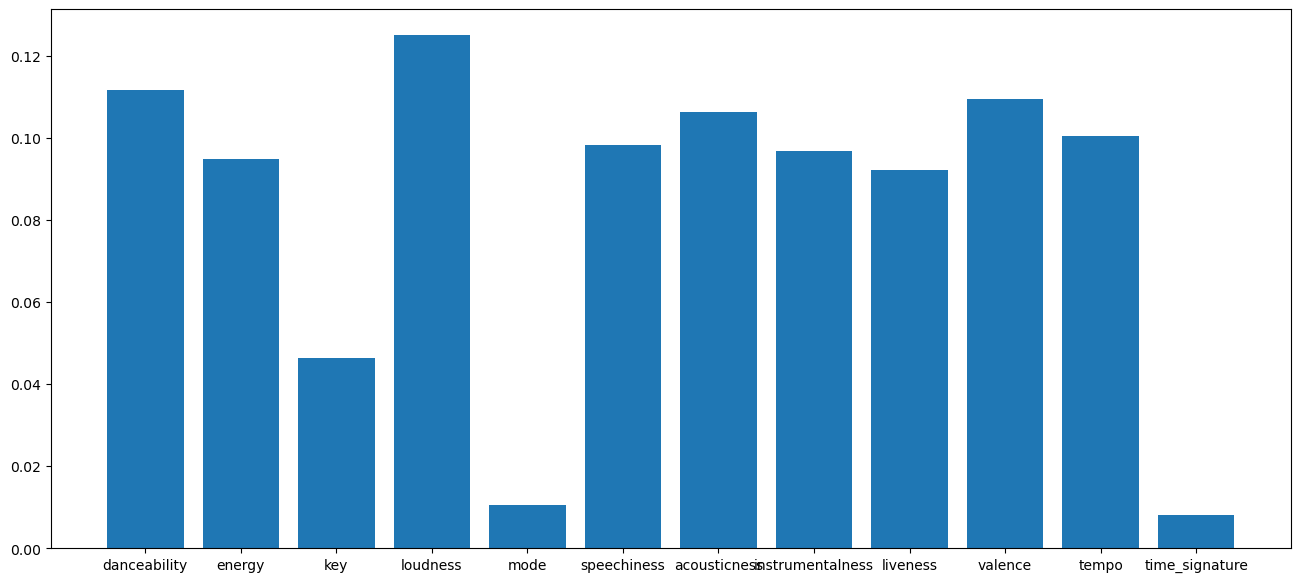

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,7))

plt.bar(X.columns, RF_model.feature_importances_)
plt.xticks(rotation=45)
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

The feature importance scores obtained from the Random Forest model are visualized using a bar chart to provide a clearer comparison between the predictor variables.

The results indicate that `Loudness` is the most influential feature in predicting song popularity, followed by `Danceability`, `Valence`, `Acousticness`, and `Tempo`. In contrast, variables such as `Mode` and `Time Signature` contribute very little to the prediction task.

### Multicollinearity Audit

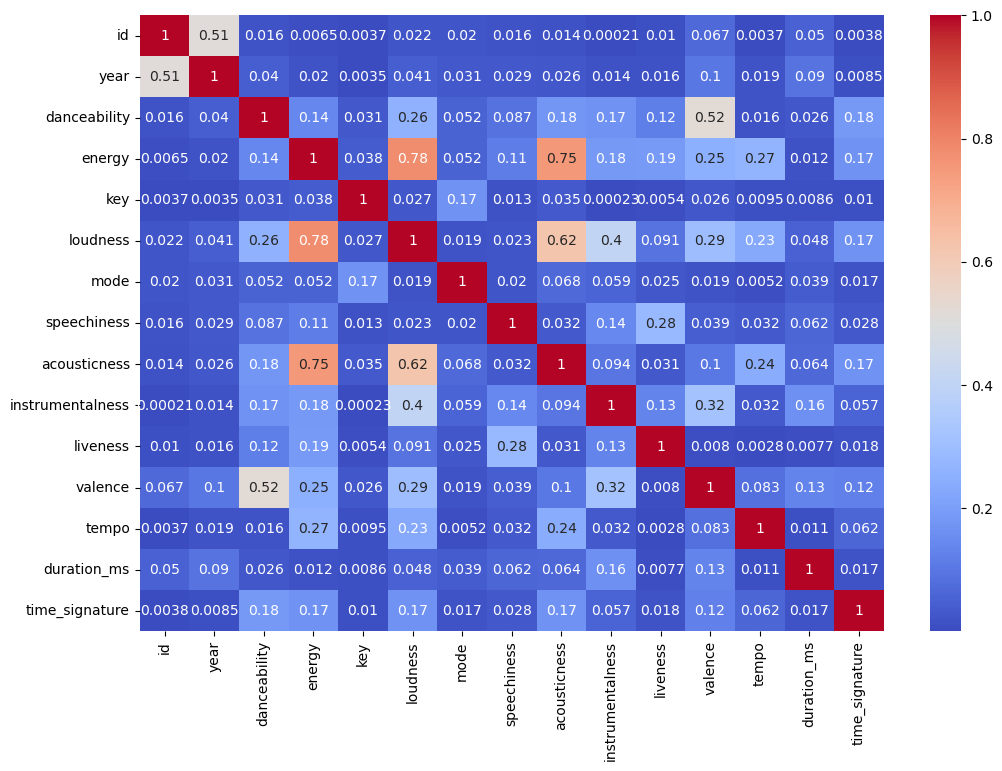

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data=data.select_dtypes(include='number').drop(columns='popularity')
corr_matrix=numeric_data.corr().abs()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.show()


To identify redundant features, a Pearson correlation matrix was computed for all numerical variables. Highly correlated features contain similar information, which may introduce unnecessary complexity and redundancy into the neural network.

The correlation analysis revealed that `Energy` and `Loudness` have a strong positive correlation (0.78). In addition, `Energy` also shows a strong correlation with `Acousticness` (0.75). These high correlation values indicate that the Energy feature overlaps considerably with other audio characteristics.

To determine which feature should be retained, the Random Forest feature importance analysis from previous cell was considered. `Loudness` achieved a higher importance score than `Energy` indicating that it contributes more to predicting song popularity.


In [5]:
cleaned_data=data.drop(columns='energy')
cleaned_data

,id,artist_name,track_name,track_id,popularity,year,genre,danceability,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,1054304,Cabas,Amor De Mis Amores,3FTqjWmL21xi4HTTOq94EQ,38,2006,alt-rock,0.725,6,-6.319,0,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,4
1,621408,Ketil Bjørnstad,Første sang,0Pt7ESPgrdTdaxp2f29hX2,11,2023,swedish,0.277,9,-16.743,0,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,4
2,1121669,Project 86,Evil (A Chorus Of Resistance),75Ub3ckaoTdzgH9Azeu8cY,38,2007,alt-rock,0.486,2,-4.845,0,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,4
3,439351,Ital Tek,Open Heart,5WEPna9GWi0NkqVLAkEKNN,18,2020,dubstep,0.411,1,-12.745,0,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,3
4,266036,I-Roy,Irie Right,6peHySxvmZaRF9YEwUsggq,18,2017,dancehall,0.748,10,-4.648,0,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159759,110268,Young Rising Sons,Turnin',7om9AA7nbASF0vzS2u5cDz,35,2014,alt-rock,0.623,6,-4.888,1,0.0371,0.097800,0.000000,0.1790,0.677,96.010,209467,4
1159760,259178,Joey Yung,最好時光,1GHmomEXqI3ouEC0oY5Rmb,27,2017,cantopop,0.361,5,-8.777,1,0.0280,0.816000,0.000000,0.1260,0.287,99.556,238312,4
1159761,131932,Accept,Dying Breed,7eix1TUdK0UB2pKClmOF1v,24,2014,german,0.269,4,-4.505,0,0.1130,0.000030,0.152000,0.1130,0.351,135.147,321467,4
1159762,740623,Buckfunk 3000,Jump,2lcUzu3SUdlHLjlvq2EZER,2,2001,breakbeat,0.870,5,-7.092,0,0.0928,0.000613,0.528000,0.3420,0.464,139.938,351428,4


Therefore, `Energy` was removed from the dataset while `Loudness` was retained. This reduces multicollinearity, decreases feature redundancy, and simplifies the model without discarding the more informative feature.

### Metadata Stripping

In [7]:
stripped_data=cleaned_data.drop(columns=['track_id', 'track_name','artist_name', 'id'])
stripped_data

,popularity,year,genre,danceability,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,38,2006,alt-rock,0.725,6,-6.319,0,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,4
1,11,2023,swedish,0.277,9,-16.743,0,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,4
2,38,2007,alt-rock,0.486,2,-4.845,0,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,4
3,18,2020,dubstep,0.411,1,-12.745,0,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,3
4,18,2017,dancehall,0.748,10,-4.648,0,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159759,35,2014,alt-rock,0.623,6,-4.888,1,0.0371,0.097800,0.000000,0.1790,0.677,96.010,209467,4
1159760,27,2017,cantopop,0.361,5,-8.777,1,0.0280,0.816000,0.000000,0.1260,0.287,99.556,238312,4
1159761,24,2014,german,0.269,4,-4.505,0,0.1130,0.000030,0.152000,0.1130,0.351,135.147,321467,4
1159762,2,2001,breakbeat,0.870,5,-7.092,0,0.0928,0.000613,0.528000,0.3420,0.464,139.938,351428,4


Before preparing the dataset for model training, identifier and metadata columns that do not provide meaningful predictive information were removed.

The columns `track_id`, `track_name`, `artist_name`, and `id` were excluded because they represent unique identifiers or descriptive information rather than measurable audio characteristics. 
Including these variables could introduce noise or allow the model to learn irrelevant patterns that do not generalize to new songs.

The remaining dataset focuses only on audio features that describe the musical characteristics of each track, allowing the neural network to learn relationships between audio properties and popularity classes more effectively.

### Outlier Management

In [8]:
from scipy.stats import zscore

data = stripped_data.copy()

columns_to_check = ['danceability', 'loudness', 'speechiness', 
                    'acousticness', 'instrumentalness', 'liveness',
                    'valence', 'tempo', 'duration_ms']

original_rows = len(data)

z_score = data[columns_to_check].apply(zscore)

mask = (z_score.abs() < 3).all(axis=1)

data = data[mask]
data.reset_index(drop=True, inplace=True)

print("Rows before outlier removal:", original_rows)
print("Rows after outlier removal:", len(data))
print("Removed rows:", original_rows - len(data))

Rows before outlier removal: 1159764
Rows after outlier removal: 1073825
Removed rows: 85939


Extreme observations may represent noise rather than meaningful musical characteristics.

Z-score filtering (|z| < 3) is applied to remove these observations before model training.

### Smart Hit Labeling

In [9]:
import numpy as np

driver_feature="loudness"
top30_pop=data["popularity"].quantile(0.70)
top30_feature=data[driver_feature].quantile(0.70)

median_pop=data["popularity"].median()
median_feature=data[driver_feature].median()

labels=[]
for i in range(len(data)):
    popularity=data["popularity"].iloc[i]
    loudness=data["loudness"].iloc[i]

    if popularity >= top30_pop and loudness >= top30_feature:
        labels.append(2)
    elif popularity >= top30_pop or loudness >= top30_feature:
        labels.append(1)
    elif popularity <= median_pop and loudness <= median_feature:
        labels.append(0)
    else:
        labels.append(1)

to_array=np.array(labels)

unique, counts=np.unique(to_array, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

data['hit_class']=labels

Class 0: 298366
Class 1: 656951
Class 2: 118508


This converts the problem into multiclass classification.

Instead of using arbitrary popularity thresholds, songs are categorized using both popularity and the most important audio feature.

This creates labels that better represent real-world song quality.

### Cyclical Encoding

In [10]:
import numpy as np
data["key_sin"] = np.sin(2 * np.pi * data["key"] / 12)
data["key_cos"] = np.cos(2 * np.pi * data["key"] / 12)

data=data.drop(columns=['key'])


Musical keys are converted into cyclical sine/cosine representations, while genres are frequency encoded.

### Frequency Encoding 

In [11]:
frequency_genre=data['genre'].value_counts(ascending=False)

data['encoded_genre']=data['genre'].map(frequency_genre)

data=data.drop(columns=['genre'])
data


,popularity,year,danceability,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,hit_class,key_sin,key_cos,encoded_genre
0,38,2006,0.725,-6.319,0,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,4,1,1.224647e-16,-1.000000e+00,20495
1,11,2023,0.277,-16.743,0,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,4,0,-1.000000e+00,-1.836970e-16,10848
2,38,2007,0.486,-4.845,0,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,4,2,8.660254e-01,5.000000e-01,20495
3,18,2020,0.411,-12.745,0,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,3,1,5.000000e-01,8.660254e-01,4615
4,18,2017,0.748,-4.648,0,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,4,1,-8.660254e-01,5.000000e-01,18156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073820,35,2014,0.623,-4.888,1,0.0371,0.097800,0.000000,0.1790,0.677,96.010,209467,4,2,1.224647e-16,-1.000000e+00,20495
1073821,27,2017,0.361,-8.777,1,0.0280,0.816000,0.000000,0.1260,0.287,99.556,238312,4,1,5.000000e-01,-8.660254e-01,14944
1073822,24,2014,0.269,-4.505,0,0.1130,0.000030,0.152000,0.1130,0.351,135.147,321467,4,1,8.660254e-01,-5.000000e-01,14486
1073823,2,2001,0.870,-7.092,0,0.0928,0.000613,0.528000,0.3420,0.464,139.938,351428,4,1,5.000000e-01,-8.660254e-01,12019


Categorical features cannot be processed directly by neural networks.

### Robust Scaling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_final=data.drop(columns=['popularity','mode','time_signature','year','hit_class'])
y_final=data['hit_class']

X_train_full, X_test, y_train_full, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

scaler=StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

data

,popularity,year,danceability,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,hit_class,key_sin,key_cos,encoded_genre
0,38,2006,0.725,-6.319,0,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,4,1,1.224647e-16,-1.000000e+00,20495
1,11,2023,0.277,-16.743,0,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,4,0,-1.000000e+00,-1.836970e-16,10848
2,38,2007,0.486,-4.845,0,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,4,2,8.660254e-01,5.000000e-01,20495
3,18,2020,0.411,-12.745,0,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,3,1,5.000000e-01,8.660254e-01,4615
4,18,2017,0.748,-4.648,0,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,4,1,-8.660254e-01,5.000000e-01,18156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073820,35,2014,0.623,-4.888,1,0.0371,0.097800,0.000000,0.1790,0.677,96.010,209467,4,2,1.224647e-16,-1.000000e+00,20495
1073821,27,2017,0.361,-8.777,1,0.0280,0.816000,0.000000,0.1260,0.287,99.556,238312,4,1,5.000000e-01,-8.660254e-01,14944
1073822,24,2014,0.269,-4.505,0,0.1130,0.000030,0.152000,0.1130,0.351,135.147,321467,4,1,8.660254e-01,-5.000000e-01,14486
1073823,2,2001,0.870,-7.092,0,0.0928,0.000613,0.528000,0.3420,0.464,139.938,351428,4,1,5.000000e-01,-8.660254e-01,12019


StandardScaler is fitted only on the training data to prevent data leakage.

The fitted scaler is then applied to the validation and test sets.

### ANN Architecture Design

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU
from keras.optimizers import Adam

model=Sequential()

model.add(Dense(512, input_shape=(X_train_scaled.shape[1],)))
model.add(LeakyReLU(negative_slope=0.01))

model.add(Dense(256, activation='tanh'))

model.add(Dense(64))
model.add(LeakyReLU(negative_slope=0.01))

model.add(Dense(3, activation='softmax'))

model.summary()


model.compile(
    optimizer=Adam() ,
    loss='sparse_categorical_crossentropy' ,
    metrics=['accuracy']
)


C:\Users\golsa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,627 (604.01 KB)

 Trainable params: 154,627 (604.01 KB)

 Non-trainable params: 0 (0.00 B)

A deep neural network is constructed to model the nonlinear relationship between Spotify audio characteristics and hit potential.

The network uses LeakyReLU and Tanh activations together with a Softmax output layer for multiclass classification.

### Scale & Stability Experiment

Two training scenarios are compared:

• Scenario A: 5% of the data

• Scenario B: Full dataset


The objective is to evaluate the effect of dataset size on model performance while using ReduceLROnPlateau to stabilize training.
#### scenario A: Baseline Training (5% Dataset)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, LeakyReLU
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau

model_A=Sequential()

model_A.add(Dense(512, input_shape=(X_train_scaled.shape[1],)))
model_A.add(LeakyReLU(negative_slope=0.01))

model_A.add(Dense(256, activation='tanh'))

model_A.add(Dense(64))
model_A.add(LeakyReLU(negative_slope=0.01))

model_A.add(Dense(3, activation='softmax'))

model_A.compile(
    optimizer=Adam() ,
    loss='sparse_categorical_crossentropy' ,
    metrics=['accuracy']
)


reduce_lr=ReduceLROnPlateau(monitor='val_accuracy',
                            factor=0.5,
                            patience=3,
                            min_lr=1e-6,
                           verbose=1)

# 5% of the dataset
X_train_5, _, y_train_5, _ = train_test_split(X_train_scaled, y_train,
                                              test_size=0.95, random_state=42,
                                              stratify=y_train)

history_a=model_A.fit(X_train_5,y_train_5,
          validation_data=(X_val_scaled,y_val),
         epochs=100,
         batch_size=128,
        callbacks=[reduce_lr],
         verbose=1)
model_A.save('model-a.keras')

Epoch 1/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.6784 - loss: 0.5967 - val_accuracy: 0.7062 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 2/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7020 - loss: 0.5372 - val_accuracy: 0.7079 - val_loss: 0.5298 - learning_rate: 0.0010
Epoch 3/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.7082 - loss: 0.5244 - val_accuracy: 0.7118 - val_loss: 0.5199 - learning_rate: 0.0010
Epoch 4/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7101 - loss: 0.5201 - val_accuracy: 0.7161 - val_loss: 0.5227 - learning_rate: 0.0010
Epoch 5/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.7142 - loss: 0.5146 - val_accuracy: 0.7051 - val_loss: 0.5318 - learning_rate: 0.0010
Epoch 6/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7170 - loss: 0.5117 - val_accuracy: 0.7133 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 7/100
250/252 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.72

The relatively small difference between the training and validation accuracies suggests that the model generalized reasonably well despite being trained on only a small subset of the available data. Although the validation loss remained slightly higher than the training loss, no severe overfitting was observed.

The automatic learning rate scheduling gradually reduced the learning rate to **1 × 10⁻⁶**, allowing the model to converge smoothly once validation performance plateaued.



This experiment demonstrates that even a relatively small portion of the dataset contains sufficient information for the neural network to learn meaningful relationships between the audio features and the generated popularity classes.

#### scenario B

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, LeakyReLU
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau

model_B=Sequential()

model_B.add(Dense(512, input_shape=(X_train_scaled.shape[1],)))
model_B.add(LeakyReLU(negative_slope=0.01))

model_B.add(Dense(256, activation='tanh'))

model_B.add(Dense(64))
model_B.add(LeakyReLU(negative_slope=0.01))

model_B.add(Dense(3, activation='softmax'))

model_B.compile(
    optimizer=Adam() ,
    loss='sparse_categorical_crossentropy' ,
    metrics=['accuracy']
)

reduce_lr=ReduceLROnPlateau(monitor='val_accuracy',
                            factor=0.5,
                            patience=5,
                            min_lr=1e-6,
                           verbose=1)

history_b=model_B.fit(X_train_scaled,y_train,
          validation_data=(X_val_scaled,y_val),
         epochs=100,
         batch_size=2048,
        callbacks=[reduce_lr],
         verbose=1)

model_B.save('model-b.keras')

C:\Users\golsa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.7048 - loss: 0.5455 - val_accuracy: 0.7202 - val_loss: 0.5084 - learning_rate: 0.0010
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7200 - loss: 0.5059 - val_accuracy: 0.7217 - val_loss: 0.5029 - learning_rate: 0.0010
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7252 - loss: 0.4992 - val_accuracy: 0.7283 - val_loss: 0.4970 - learning_rate: 0.0010
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7293 - loss: 0.4942 - val_accuracy: 0.7313 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7309 - loss: 0.4916 - val_accuracy: 0.7298 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 6/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7334 - loss: 0.4885 - val_accuracy: 0.7361 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 7/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.73


The second experiment evaluates the performance of the proposed neural network when trained on the **entire processed training dataset**. Unlike Scenario A, which used only 5% of the available data, this experiment leverages all training samples to determine whether increasing the amount of data improves the model's ability to generalize.

To efficiently process the large dataset, a **batch size of 2048** was used. In addition, the **ReduceLROnPlateau** callback continuously monitored the validation accuracy and automatically reduced the learning rate whenever the model stopped improving, allowing the optimizer to perform finer weight updates during the later stages of training.

### Results

Compared with Scenario A, both the training and validation performances improved noticeably. The validation accuracy increased from **72.30%** to **77.64%**, while both the training and validation losses decreased, indicating that the model learned a more robust representation of the data.

Throughout training, the **ReduceLROnPlateau** callback gradually decreased the learning rate to **3.91 × 10⁻⁶**, enabling the optimizer to make increasingly smaller adjustments as the model approached convergence. This adaptive learning strategy contributed to a smoother optimization process and helped stabilize the final training stages.


Training the model on the complete dataset consistently improved its predictive performance across all evaluation metrics. Compared with the baseline experiment, the full-scale model achieved higher training and validation accuracies while simultaneously reducing both training and validation losses.

The improvement demonstrates that exposing the neural network to a larger and more diverse collection of songs allows it to learn richer feature representations and generalize more effectively to unseen data.

Although the increase in accuracy is moderate, the improvement is consistent across all evaluation metrics, indicating that the additional training data contributed to a more reliable and better-generalized model rather than simply increasing training performance.


Overall, Scenario B produced the best-performing model and was therefore selected as the final model for the subsequent evaluation and deployment tasks.

### Confusion Matrix Analysis

6712/6712 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step


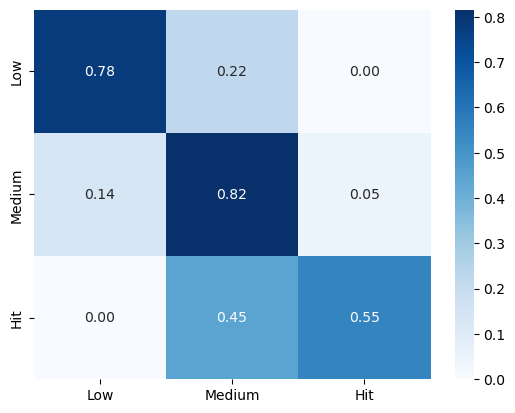

<Figure size 600x500 with 0 Axes>

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_probs=model_B.predict(X_test_scaled)
y_pred_class=np.argmax(y_pred_probs, axis=1)

plt.figure(figsize=(6, 5))

cm=confusion_matrix(y_test, y_pred_class, normalize='true')
sns.heatmap(cm,annot=True, fmt=".2f", cmap="Blues",
    xticklabels=["Low", "Medium", "Hit"],
    yticklabels=["Low", "Medium", "Hit"])

plt.show()

To better understand the classification performance of the final neural network, a normalized confusion matrix was generated using the test dataset. Each row represents the true class, while each column represents the predicted class. Since the matrix is normalized, each row sums to 100%, making it easier to evaluate how well the model performs for each popularity category.


The confusion matrix shows that:

- **Low Performance:** Approximately **78%** of low-performing songs were correctly classified as **Low**, while about **22%** were mistakenly classified as **Medium**. None of the low-performing songs were incorrectly predicted as **Hit**.

- **Potential / Medium:** The model correctly identified about **82%** of medium-performing songs, making this the **best predicted class**. Only a small proportion of these songs were misclassified as either **Low (14%)** or **Hit (5%)**.

- **High-Quality Hit:** Around **55%** of hit songs were correctly recognized as **Hit**, while **45%** were predicted as **Medium**. Importantly, almost no hit songs were incorrectly classified as **Low**, indicating that the model generally recognizes successful songs but sometimes struggles to distinguish between **Medium** and **Hit**.



Overall, the confusion matrix indicates that the model performs well across all three classes, with particularly strong performance for the **Medium** category. The majority of prediction errors occur between the **Medium** and **Hit** classes rather than between **Low** and **Hit**.

This behavior is expected because songs with medium popularity and highly successful songs often share similar audio characteristics. As a result, the neural network occasionally assigns a promising song to the **Medium** category instead of confidently classifying it as a **Hit**.

Despite this challenge, the model successfully separates low-performing songs from high-performing songs and demonstrates a strong overall ability to classify the generated popularity classes.

### Comparative Loss Curves

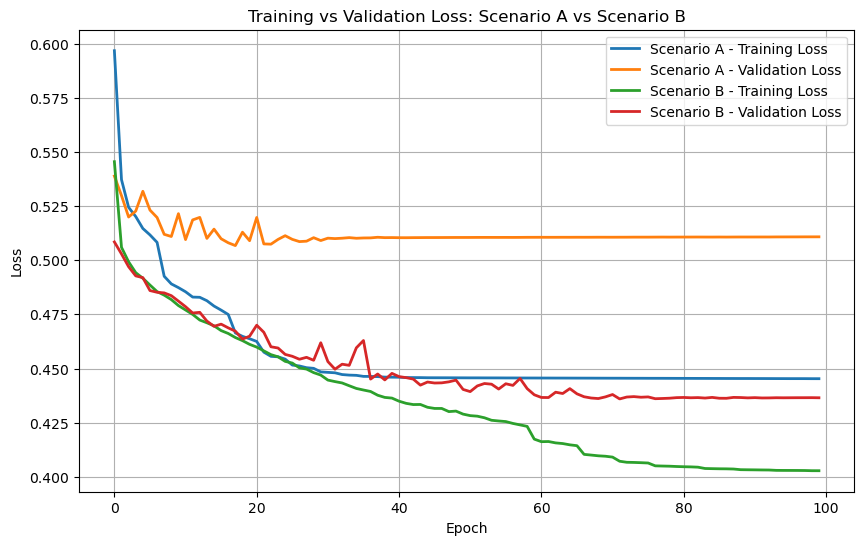

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Scenario A
plt.plot(history_a.history['loss'],label='Scenario A - Training Loss',linewidth=2)

plt.plot(history_a.history['val_loss'] ,label='Scenario A - Validation Loss',linewidth=2)


# Scenario B
plt.plot(history_b.history['loss'], label='Scenario B - Training Loss',linewidth=2)

plt.plot(history_b.history['val_loss'] ,label='Scenario B - Validation Loss',linewidth=2)


plt.title('Training vs Validation Loss: Scenario A vs Scenario B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Training and validation loss curves are compared for both scenarios to evaluate convergence, overfitting, and generalization.

## Training and Validation Loss Comparison

To better understand the learning behavior of both models, the training and validation losses were monitored throughout the training process. Comparing these curves provides valuable insight into model convergence, generalization, and the effect of training with different amounts of data.


The loss curves reveal several important observations:


- **Scenario A (5% of the dataset):** Both the training and validation losses decreased rapidly during the early epochs, indicating that the model quickly learned the basic patterns within the limited dataset. However, after approximately **30 epochs**, the validation loss stopped improving and stabilized around **0.51**, while the training loss continued to decrease slightly. This suggests that the model had extracted most of the useful information available from the small training subset.

- **Scenario B (100% of the dataset):** The training and validation losses decreased steadily throughout the training process and converged to noticeably lower values than those observed in Scenario A. The final training loss reached approximately **0.40**, while the validation loss decreased to around **0.44**. The continuous reduction in both curves indicates that the model continued learning meaningful patterns from the larger dataset even during the later training epochs.


Comparing the two experiments clearly demonstrates the benefit of training on a larger dataset. While both models successfully converged, the full-scale model achieved consistently lower training and validation losses, indicating that it learned a more accurate representation of the underlying relationships between the audio features and the generated popularity classes.

Another important observation is that the gap between the training and validation losses remains relatively small in both scenarios. This suggests that the neural network generalizes well to unseen data and does not exhibit severe overfitting.

Overall, the loss curves support the findings from the accuracy metrics presented. The model trained on the complete dataset not only achieved higher predictive accuracy but also converged to a lower and more stable loss, demonstrating the advantage of utilizing a larger and more diverse training set.

In [21]:
import pandas as pd
import numpy as np

def predict_song(danceability, loudness, speechiness,
                 acousticness, instrumentalness, liveness,
                 valence, tempo, duration_ms,
                 key, genre):

    
    key_sin = np.sin(2 * np.pi * key / 12)
    key_cos = np.cos(2 * np.pi * key / 12)

    
    if genre not in frequency_genre.index:
        print("Genre not found in dataset.")
        return

    encoded_genre = frequency_genre[genre]

    
    new_song = pd.DataFrame({
        "danceability": [danceability],
        "loudness": [loudness],
        "speechiness": [speechiness],
        "acousticness": [acousticness],
        "instrumentalness": [instrumentalness],
        "liveness": [liveness],
        "valence": [valence],
        "tempo": [tempo],
        "duration_ms": [duration_ms],
        "key_sin": [key_sin],
        "key_cos": [key_cos],
        "encoded_genre": [encoded_genre]
    })

    
    new_song_scaled = scaler.transform(new_song)

    
    probabilities = model_B.predict(new_song_scaled, verbose=0)[0]

    print(f" Low Performance     : {probabilities[0]*100:.2f}%")
    print(f" Potential / Niche   : {probabilities[1]*100:.2f}%")
    print(f" High-Quality Hit    : {probabilities[2]*100:.2f}%")
    print()

    classes = ["Low Performance", "Potential / Niche", "High-Quality Hit"]
    print("Prediction:", classes[np.argmax(probabilities)])



predict_song(
    danceability=0.82,
    loudness=-5.2,
    speechiness=0.04,
    acousticness=0.18,
    instrumentalness=0.00,
    liveness=0.11,
    valence=0.73,
    tempo=122,
    duration_ms=210000,
    key=5,
    genre="acoustic"
)

🟥 Low Performance     : 0.00%
🟨 Potential / Niche   : 16.41%
🟩 High-Quality Hit    : 83.59%

Prediction: High-Quality Hit


To demonstrate a practical application of the trained neural network, a **Virtual A&R (Artists and Repertoire) Hit Simulator** was developed. The simulator allows a user to enter the audio characteristics of a hypothetical song and receive the predicted probability of the song belonging to each popularity class.

The function performs the same preprocessing steps that were applied during model training.
The processed song is then passed to the final neural network (`model_B`), which outputs the probability of the song belonging to each popularity category.



For the example song, the model predicted:

- **Low Performance:** **0.00%**
- **Potential / Niche:** **16.41%**
- **High-Quality Hit:** **83.59%**

Based on these probabilities, the song was classified as a **High-Quality Hit**.



The prediction indicates that the proposed song shares audio characteristics commonly found in successful tracks within the training dataset. Rather than returning only a single class label, the simulator provides a **probability distribution** across all three classes, allowing the prediction confidence to be interpreted more effectively.

In this example, the model assigned more than **83% confidence** to the **High-Quality Hit** class while assigning virtually no probability to the **Low Performance** class. This suggests that the model is highly confident that the song exhibits the characteristics associated with commercially successful tracks.



A prediction system such as this could assist music labels, producers, and A&R teams during the early evaluation of new songs. Instead of relying solely on subjective judgment, decision-makers could use the predicted probabilities as an additional source of information when prioritizing tracks for promotion.

For example, songs receiving a high probability of belonging to the High-Quality Hit class could be considered stronger candidates for larger marketing campaigns, playlist promotion, or commercial release. Conversely, songs with lower confidence scores might benefit from further production or targeted promotion before release.

Although the model is not intended to replace human expertise, it demonstrates how machine learning can support data-driven decision making within the music industry.

---

## Real-World Application

One of the primary goals of this project is to demonstrate how machine learning can support decision-making within the music industry. Rather than replacing human expertise, the proposed model can serve as an **A&R (Artists and Repertoire) decision-support tool** by estimating a song's commercial potential before it is officially released.

The probability values produced by the neural network can be interpreted as a **Confidence Score**, indicating how strongly the model believes that a song belongs to each popularity class. Instead of relying only on the predicted class label, music labels can use these probabilities to prioritize their marketing investments.

For example:

- A song with a **90% probability** of being classified as a **High-Quality Hit** may be considered a strong candidate for increased marketing investment, playlist promotion, music video production, and international distribution.

- A song with probabilities distributed more evenly across multiple classes (e.g., **45% Hit**, **40% Potential**, **15% Low**) represents a less certain prediction. In such cases, record labels may choose to perform additional market testing, audience surveys, or release the song with a smaller promotional budget before committing further resources.

- Songs predicted with a high probability of **Low Performance** may still be released, but with lower promotional spending, allowing marketing resources to be allocated more efficiently across the artist's catalog.

Using the prediction probabilities instead of only the final class enables decision-makers to evaluate not only **what** the model predicts, but also **how confident** the prediction is. This provides a more informative and practical basis for resource allocation than a simple binary recommendation.

---

## Final Conclusion

This project demonstrates that deep neural networks can successfully learn meaningful relationships between Spotify audio features and song popularity. Through feature engineering, careful preprocessing, and large-scale training, the proposed model achieved strong predictive performance while maintaining good generalization on unseen data.

Although the model effectively distinguishes between low-performing, medium-performing, and high-quality hit songs, audio features alone cannot fully explain commercial success. Real-world popularity is also influenced by external factors such as artist reputation, marketing strategy, playlist exposure, social media engagement, cultural trends, and release timing.
